In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

In [4]:
data = pd.read_csv('AirPassengers.csv', index_col='Month', parse_dates=True)
data.index.freq = 'MS' 

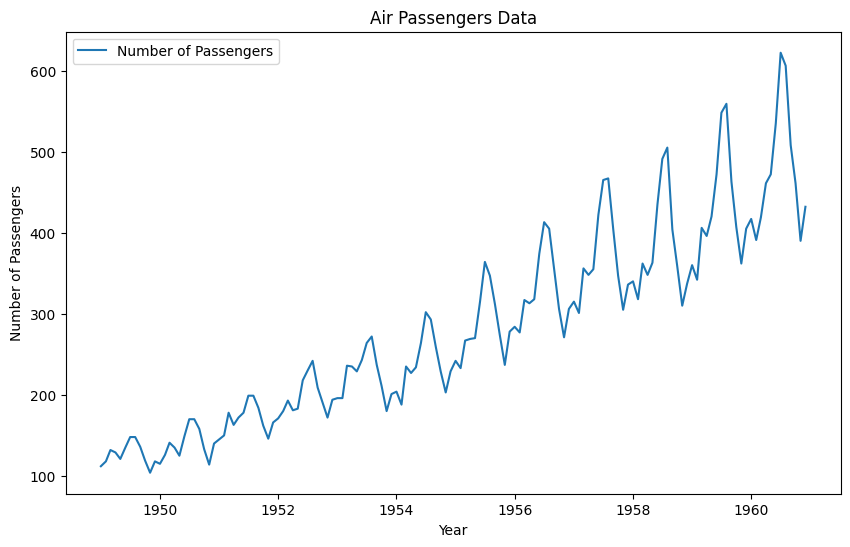

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(data, label='Number of Passengers')
plt.title('Air Passengers Data')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [7]:
model = ARIMA(data['#Passengers'], order=(2, 1, 2))
arima_result = model.fit()
print(arima_result.summary()) 

                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Sun, 09 Nov 2025   AIC                           1353.347
Time:                        18:35:26   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.061      0.000       1.645       1.725
ar.L2         -0.9549      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.124    -14.856      0.0

/Users/akash/Collage/ML/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [8]:
forecast_steps = 12 # Forecast for the next 12 months
forecast = arima_result.forecast(steps=forecast_steps)

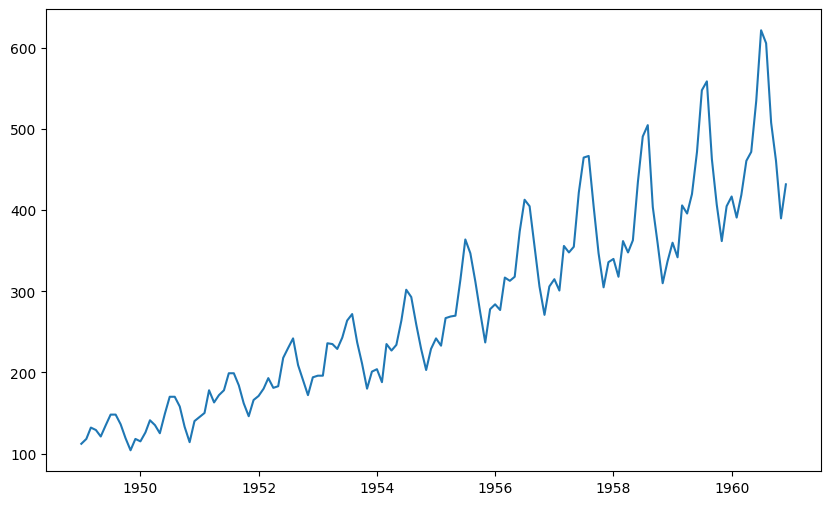

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(data, label='Historical Data')

forecast_index = pd.date_range(start=data.index[-1] + data.index.freq, 
                               periods=forecast_steps, 
                               freq='MS')

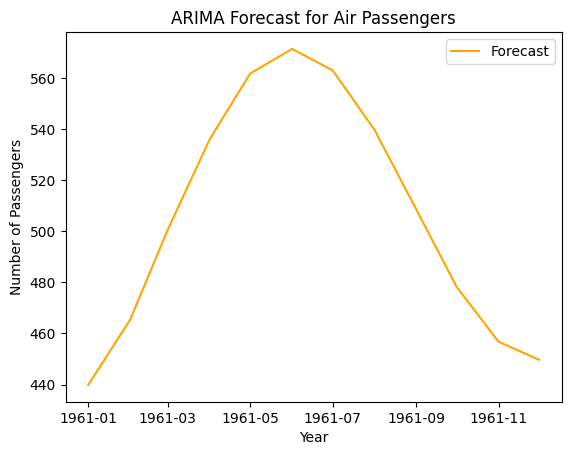

In [ ]:
plt.plot(forecast_index, forecast, label='Forecast', color='orange')
plt.title('ARIMA Forecast for Air Passengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()